# W8 trametinib time-course analysis

## tl;dr

정상 세포 13,713개를 24개 cell line × 11개 condition/time 그룹으로
pseudobulk했다. 모든 DMSO/Tram 시점에서 조건별 10개 이상 세포가 있는 22개를
주 코호트로 사용했다. Immediate-early 8-gene 반응은 3시간부터 강한 억제를
보였고, E2F/G2M 억제는 12–48시간에 커졌다. 반면 cross-line 이질성이 후기에
더 커진다는 paired 차이는 0을 포함했다. 94-line 24h 모델은 겹치는 DepMap ID를
제외한 17개 외부 line에서 24h와 48h에만 B1보다 작지만 양의 RMSE 이득을 보였다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists() and (path / "cell_count_matrix.csv").exists()
)


In [2]:
summary = json.loads((root / "results/logs/temporal_summary.json").read_text())
validation = json.loads((root / "results/logs/temporal_validation.json").read_text())
cohort = pd.read_csv(root / "results/tables/timecourse_cohort.csv")
heterogeneity = pd.read_csv(root / "results/tables/temporal_heterogeneity_summary.csv")
pathways = pd.read_csv(root / "results/tables/timecourse_pathway_summary.csv")
transfer = pd.read_csv(root / "results/tables/temporal_transfer_summary.csv")

display(pd.DataFrame({
    "metric": ["normal assigned cells", "all lines", "primary lines",
               "external transfer lines", "response reconstruction max error"],
    "value": [summary["cohort"]["normal_assigned_cells"],
              summary["cohort"]["cell_lines_all"],
              summary["cohort"]["cell_lines_t10"],
              summary["external_transfer"]["external_test_lines"],
              validation["max_response_reconstruction_error"]],
}))
assert validation["status"] == "passed"
assert validation["training_depmap_overlap"] == 0
assert validation["temporal_response_used_for_fit"] is False


,metric,value
0,normal assigned cells,13713.0
1,all lines,24.0
2,primary lines,22.0
3,external transfer lines,17.0
4,response reconstruction max error,0.0


## Context & Methods

### Key Assumptions

- condition과 시간은 `perturbation`/`time`이 아니라 실제 multiplexing `hash_tag`에서 읽는다.
- `cell_quality == normal`만 포함하고 `singlet_ID`를 canonical cell-line ID로 쓴다.
- 주 Δ는 각 시점의 `Tram − DMSO`; `Untreated_48hr`는 DMSO 48h QC에만 쓴다.
- 22-line 주 코호트는 10개 matched group 모두에서 ≥10 cells인 line이다.
- 공통 PCA는 전체 time course 기술용이며 예측 모델 선택에 사용하지 않는다.
- 전이 모델은 strict 94-line 24h에서만 fit하며 겹치는 DepMap ID 5개를 제외한다.
- 각 time point는 독립 표본 관찰이며 paired single-cell trajectory가 아니다.

## Data

In [3]:
from yakseopdong.pseudobulk import read_vector_parquet

pb_meta, pb = read_vector_parquet(
    root / "data/processed/pseudobulk_timecourse.parquet", "log1p_cpm"
)
response_meta, response = read_vector_parquet(
    root / "data/processed/response_timecourse.parquet", "delta_log1p_cpm"
)
print("pseudobulk_timecourse", pb_meta.shape, pb.shape)
print("response_timecourse", response_meta.shape, response.shape)
display(cohort)
assert pb.shape == (264, 32738)
assert response.shape == (120, 32738)
assert cohort["eligible_t10"].sum() == 22


pseudobulk_timecourse (264, 11) (264, 32738)
response_timecourse (120, 12) (120, 32738)


,depmap_id,cell_line,disease,matched_group_count,min_cells_across_matched_groups,eligible_t10,eligible_t20,eligible_t30
0,ACH-000415,BICR6_UPPER_AERODIGESTIVE_TRACT,head and neck cancer,10,16,True,False,False
1,ACH-000228,BICR31_UPPER_AERODIGESTIVE_TRACT,head and neck cancer,10,37,True,True,True
2,ACH-000927,BT474_BREAST,breast cancer,10,14,True,False,False
3,ACH-000288,BT549_BREAST,breast cancer,10,19,True,False,False
4,ACH-000713,CAOV3_OVARY,ovarian cancer,10,23,True,True,False
5,ACH-000329,CCFSTTG1_CENTRAL_NERVOUS_SYSTEM,brain cancer,10,31,True,True,True
6,ACH-000717,COLO680N_OESOPHAGUS,esophageal cancer,10,94,True,True,True
7,ACH-000123,COV434_OVARY,ovarian cancer,10,9,False,False,False
8,ACH-000244,DKMG_CENTRAL_NERVOUS_SYSTEM,brain cancer,10,38,True,True,True
9,ACH-000672,IALM_LUNG,lung cancer,10,10,True,False,False


## Results

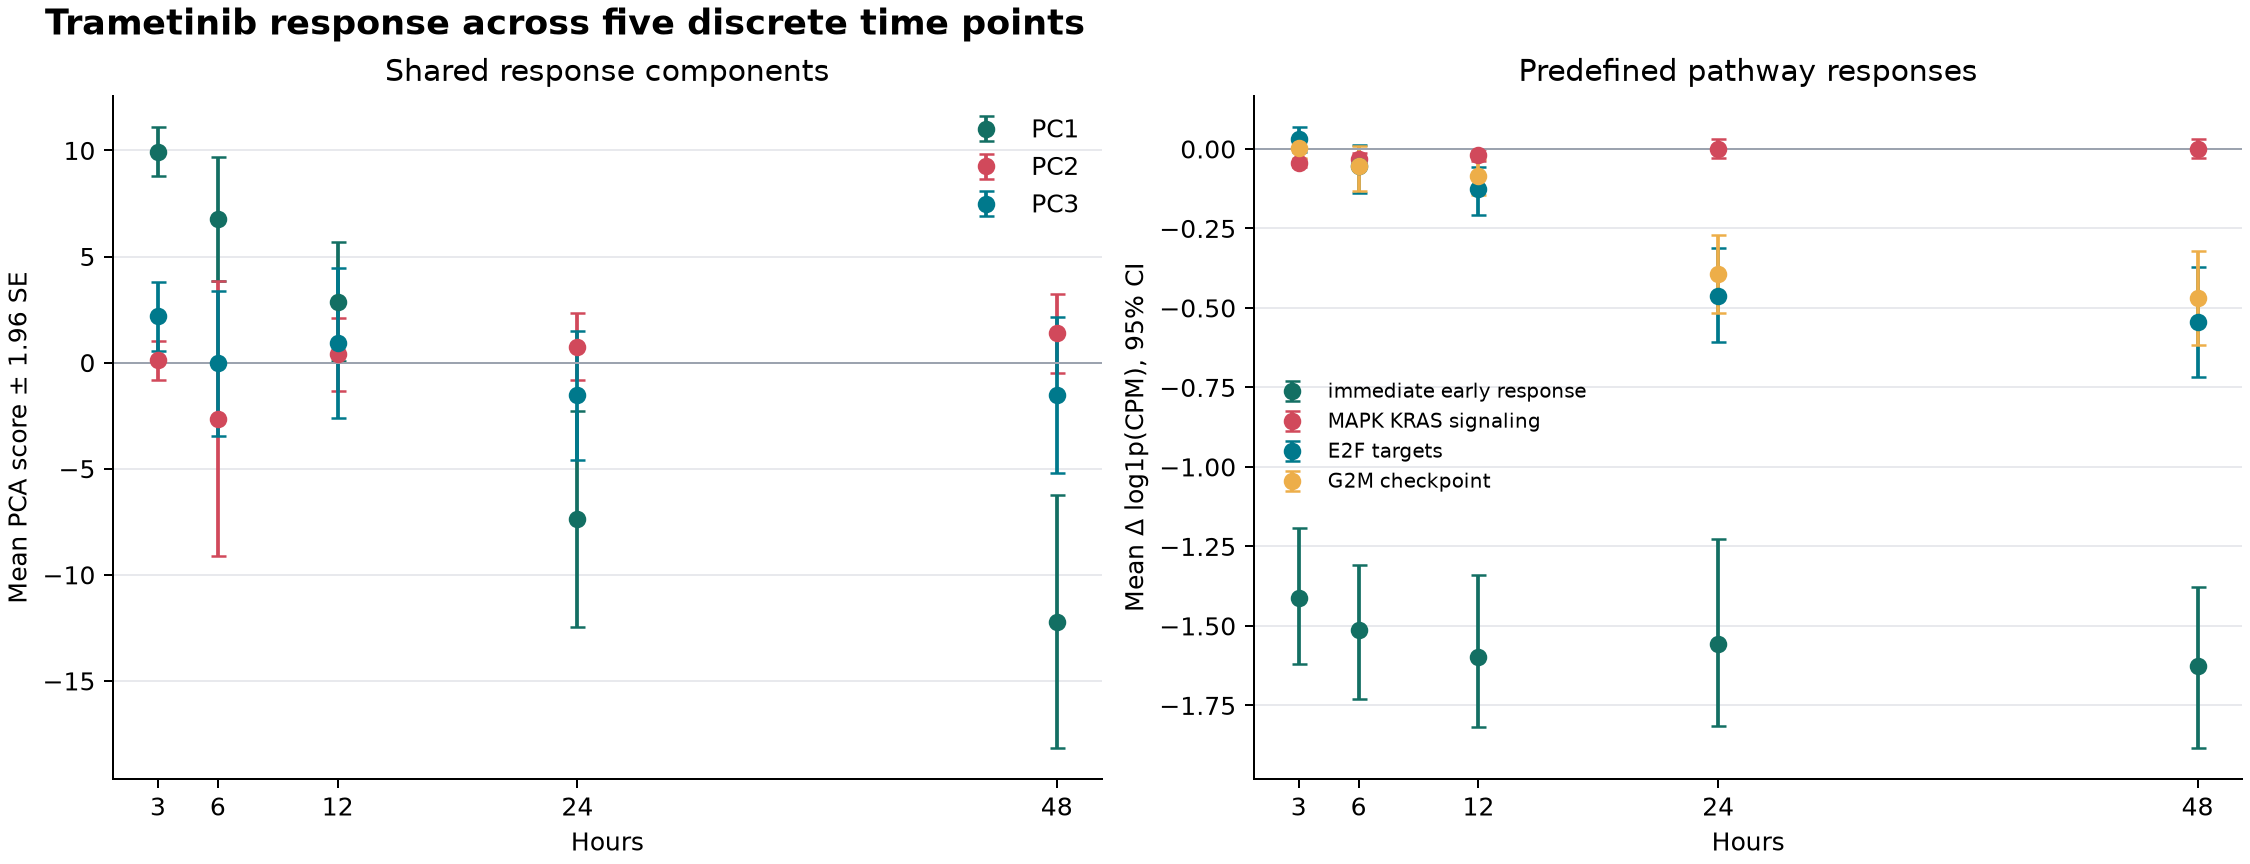

,pathway,time_hours,mapped_genes,mean_delta_log1p_cpm,ci95_low,ci95_high,cross_line_sd
0,E2F_targets,3,196,0.030442,-0.010781,0.069119,0.099833
1,E2F_targets,6,196,-0.053779,-0.138361,0.013185,0.196345
2,E2F_targets,12,196,-0.126192,-0.206545,-0.055610,0.185133
3,E2F_targets,24,196,-0.461720,-0.608688,-0.310458,0.377499
4,E2F_targets,48,196,-0.544136,-0.717960,-0.371277,0.423396
5,G2M_checkpoint,3,190,0.004451,-0.029004,0.038032,0.084911
6,G2M_checkpoint,6,190,-0.054007,-0.132741,0.009797,0.181959
7,G2M_checkpoint,12,190,-0.085591,-0.144646,-0.032995,0.137120
8,G2M_checkpoint,24,190,-0.392640,-0.515037,-0.269993,0.307100
9,G2M_checkpoint,48,190,-0.469470,-0.616836,-0.322527,0.364409


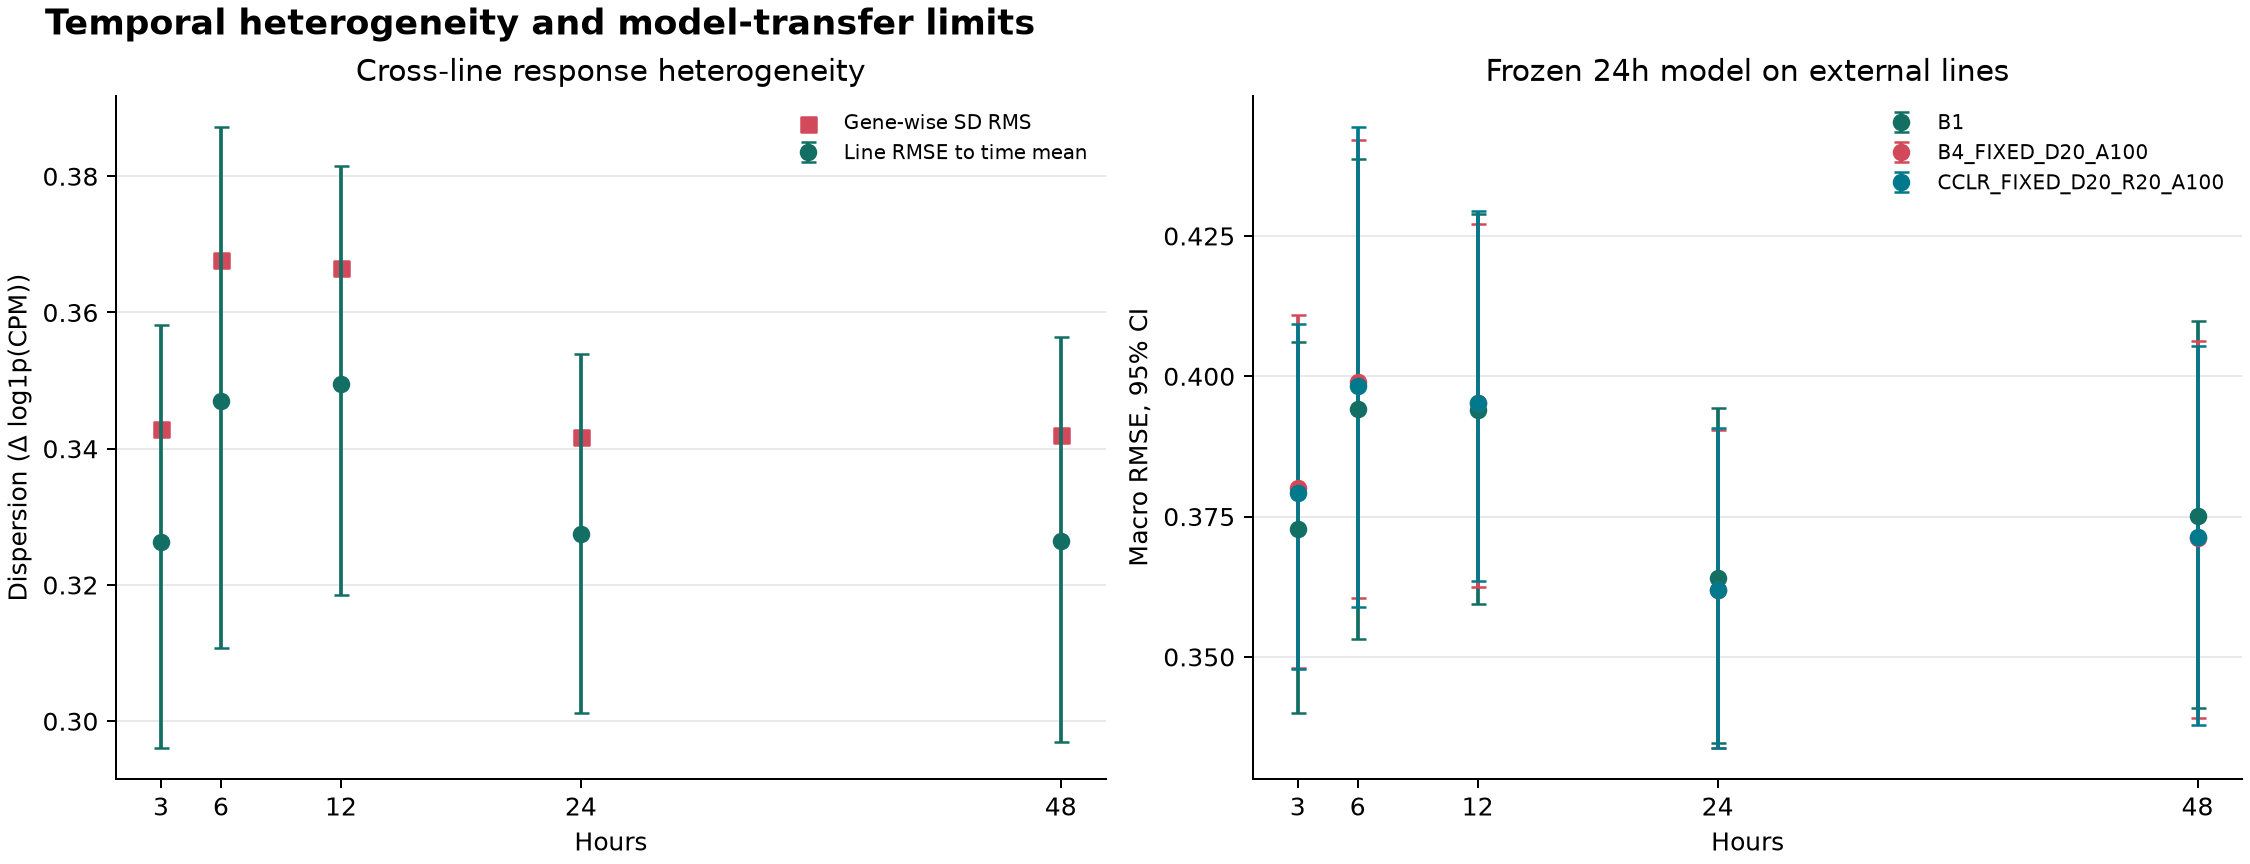

,time_hours,cross_line_gene_sd_rms,mean_line_rmse_to_time_mean,ci95_low,ci95_high
0,3,0.342825,0.326310,0.296074,0.358134
1,6,0.367761,0.346945,0.310809,0.387236
2,12,0.366461,0.349545,0.318546,0.381445
3,24,0.341660,0.327510,0.301272,0.353938
4,48,0.341951,0.326413,0.296966,0.356348


,time_hours,model,metric,macro_mean,ci95_low,ci95_high,n_cell_lines
0,3,B1,rmse_delta,0.372721,0.339917,0.406041,17
3,3,B1,rmse_gain_vs_b1,0.000000,0.000000,0.000000,17
4,3,B4_FIXED_D20_A100,rmse_delta,0.380031,0.348026,0.410966,17
7,3,B4_FIXED_D20_A100,rmse_gain_vs_b1,-0.007310,-0.010007,-0.004820,17
8,3,CCLR_FIXED_D20_R20_A100,rmse_delta,0.379183,0.347778,0.409344,17
11,3,CCLR_FIXED_D20_R20_A100,rmse_gain_vs_b1,-0.006462,-0.009500,-0.003845,17
12,6,B1,rmse_delta,0.394192,0.353245,0.438751,17
15,6,B1,rmse_gain_vs_b1,0.000000,0.000000,0.000000,17
16,6,B4_FIXED_D20_A100,rmse_delta,0.398904,0.360510,0.442056,17
19,6,B4_FIXED_D20_A100,rmse_gain_vs_b1,-0.004712,-0.007077,-0.002399,17


In [4]:
display(Image(filename=str(root / "results/figures/temporal_component_trajectories.png")))
display(pathways.loc[pathways["pathway"].isin([
    "immediate_early_response", "E2F_targets", "G2M_checkpoint"
])])
display(Image(filename=str(root / "results/figures/temporal_heterogeneity_transfer.png")))
display(heterogeneity)
display(transfer.loc[transfer["metric"].isin(["rmse_delta", "rmse_gain_vs_b1"])])


## Takeaways

- Immediate-early marker 평균은 3h부터 약 −1.41이고 48h까지 강한 음수다.
- E2F/G2M 평균은 3h에 거의 0이나 12h부터 음수, 24–48h에 크게 억제된다.
- cross-line dispersion은 6–12h가 수치상 높지만, late(24/48)−early(3/6)
  line RMSE 차이는 −0.0097 (95% CI −0.0342–0.0121)로 0을 포함한다.
- 외부 17-line에서 B4의 B1 대비 RMSE gain은 3h/6h에 음수, 12h에 불확실,
  24h 0.00207 및 48h 0.00384로 작지만 양의 CI다.
- 따라서 24h 모델은 이 데이터에서 즉시 반응용 모델이 아니며 24–48h late response에만
  제한적인 시간 전이 근거가 있다. 절대 이득은 작아 강한 개인화 모델로 해석하지 않는다.